# Step 1: Import necessary libraries for Federated Learning with TensorFlow

In [ ]:
# Import necessary libraries for Federated Learning with TensorFlow
import tensorflow as tf
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print("✓ Libraries imported successfully!")
print("✓ Ready for Federated Learning implementation")

TensorFlow version: 2.19.0
✓ Libraries imported successfully!
✓ Ready for Federated Learning implementation


# Step 2: Loading Dataset

In [ ]:
# Load GTSRB Traffic Sign Dataset
print("Loading GTSRB Traffic Sign Dataset...")

# Load training data
with open('train.p', 'rb') as f:
    train_data = pickle.load(f)

# Load validation data
with open('valid.p', 'rb') as f:
    valid_data = pickle.load(f)

# Load test data
with open('test.p', 'rb') as f:
    test_data = pickle.load(f)

# Load sign names
sign_names = pd.read_csv('signname.csv')

# Extract features and labels
X_train, y_train = train_data['features'], train_data['labels']
X_valid, y_valid = valid_data['features'], valid_data['labels']
X_test, y_test = test_data['features'], test_data['labels']

print(f"\nDataset loaded successfully!")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_valid.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Image shape: {X_train.shape[1:]}")
print(f"Number of classes: {len(np.unique(y_train))}")


Loading GTSRB Traffic Sign Dataset...

Dataset loaded successfully!
Training set: 34799 samples
Validation set: 4410 samples
Test set: 12630 samples
Image shape: (32, 32, 3)
Number of classes: 43


# Step 3: Data Preprocessing and Data Distribution

In [ ]:
# Preprocess data and distribute to 20 clients using Dirichlet distribution
print("Preprocessing data and creating federated client datasets...")

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_valid = X_valid.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Configuration
NUM_CLIENTS = 20
DIRICHLET_ALPHA = 0.5  # Controls non-IID-ness (lower = more non-IID)
NUM_CLASSES = 43

# Function to distribute data using Dirichlet distribution
def create_non_iid_client_data(X, y, num_clients, alpha):
    """
    Distribute data to clients using Dirichlet distribution for non-IID split
    """
    client_data = {i: {'X': [], 'y': []} for i in range(num_clients)}

    # For each class, distribute samples to clients
    for class_id in range(NUM_CLASSES):
        # Get indices of samples belonging to this class
        class_indices = np.where(y == class_id)[0]
        num_samples = len(class_indices)

        # Sample from Dirichlet distribution
        proportions = np.random.dirichlet(alpha=np.repeat(alpha, num_clients))

        # Distribute samples to clients based on proportions
        start_idx = 0
        for client_id in range(num_clients):
            end_idx = start_idx + int(proportions[client_id] * num_samples)

            # Assign samples to this client
            client_indices = class_indices[start_idx:end_idx]
            client_data[client_id]['X'].extend(X[client_indices])
            client_data[client_id]['y'].extend(y[client_indices])

            start_idx = end_idx

    # Convert lists to numpy arrays
    for client_id in range(num_clients):
        client_data[client_id]['X'] = np.array(client_data[client_id]['X'])
        client_data[client_id]['y'] = np.array(client_data[client_id]['y'])

    return client_data

# Create non-IID client datasets
client_datasets = create_non_iid_client_data(X_train, y_train, NUM_CLIENTS, DIRICHLET_ALPHA)

print(f"\nFederated dataset created with {NUM_CLIENTS} clients")
print(f"Dirichlet alpha: {DIRICHLET_ALPHA} (non-IID data distribution)\n")

# Display client data distribution
for client_id in range(min(5, NUM_CLIENTS)):  # Show first 5 clients
    client_size = len(client_datasets[client_id]['X'])
    unique_classes = len(np.unique(client_datasets[client_id]['y']))
    print(f"Client {client_id}: {client_size} samples, {unique_classes} unique classes")

print(f"...")
print(f"Total samples distributed: {sum([len(client_datasets[i]['X']) for i in range(NUM_CLIENTS)])}")


Preprocessing data and creating federated client datasets...

Federated dataset created with 20 clients
Dirichlet alpha: 0.5 (non-IID data distribution)

Client 0: 1720 samples, 37 unique classes
Client 1: 1178 samples, 36 unique classes
Client 2: 2098 samples, 40 unique classes
Client 3: 1569 samples, 35 unique classes
Client 4: 1767 samples, 39 unique classes
...
Total samples distributed: 34384


# Step 4: Model Definition

In [ ]:
# Define CNN model for Traffic Sign Recognition
print("Defining CNN model for traffic sign classification...")

def create_cnn_model():
    """
    Create a CNN model for GTSRB traffic sign classification (43 classes)
    """
    model = tf.keras.Sequential([
        # First Convolutional Block
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Second Convolutional Block
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.25),

        # Fully Connected Layers
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model

# Create global model
global_model = create_cnn_model()

# Compile model
global_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel architecture:")
global_model.summary()
print("\n✓ CNN model created and compiled successfully!")


Defining CNN model for traffic sign classification...

Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 909,771 (3.47 MB)

 Trainable params: 908,555 (3.47 MB)

 Non-trainable params: 1,216 (4.75 KB)


✓ CNN model created and compiled successfully!


# Step 5: Federated Learning Setup

In [ ]:
# Implement Federated Averaging (FedAvg) Algorithm
print("Implementing Federated Averaging (FedAvg) algorithm...\n")

# Federated Learning Configuration
NUM_ROUNDS = 10  # Number of federated learning rounds
LOCAL_EPOCHS = 5  # Local training epochs per client per round
BATCH_SIZE = 32
CLIENTS_PER_ROUND = 10  # Number of clients selected each round

# Metrics tracking
history = {
    'round': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

def train_client_model(client_data, global_weights, epochs=LOCAL_EPOCHS):
    """
    Train a client's local model for specified epochs
    """
    # Create a new model with global weights
    client_model = create_cnn_model()
    client_model.set_weights(global_weights)
    client_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train on client's local data
    client_model.fit(
        client_data['X'], client_data['y'],
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    return client_model.get_weights()

def federated_averaging(client_weights_list, client_sizes):
    """
    Aggregate client model weights using weighted averaging (FedAvg)
    """
    # Calculate total samples
    total_samples = sum(client_sizes)

    # Initialize averaged weights
    averaged_weights = []

    # For each layer's weights
    for layer_idx in range(len(client_weights_list[0])):
        # Weighted average of this layer across all clients
        layer_avg = np.zeros_like(client_weights_list[0][layer_idx])

        for client_idx, client_weights in enumerate(client_weights_list):
            weight = client_sizes[client_idx] / total_samples
            layer_avg += weight * client_weights[layer_idx]

        averaged_weights.append(layer_avg)

    return averaged_weights

print(f"Configuration:")
print(f"  - Federated Learning Rounds: {NUM_ROUNDS}")
print(f"  - Clients per Round: {CLIENTS_PER_ROUND} out of {NUM_CLIENTS}")
print(f"  - Local Epochs: {LOCAL_EPOCHS}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"\n✓ FedAvg algorithm implemented!")
print("\nStarting Federated Learning Training...\n")


Implementing Federated Averaging (FedAvg) algorithm...

Configuration:
  - Federated Learning Rounds: 10
  - Clients per Round: 10 out of 20
  - Local Epochs: 5
  - Batch Size: 32

✓ FedAvg algorithm implemented!

Starting Federated Learning Training...



# Step 6: Federated Learning Iterative Training

In [ ]:
# Execute Federated Learning Training Loop
import time

# Main Federated Learning Loop
for round_num in range(NUM_ROUNDS):
    round_start_time = time.time()
    print(f"\n{'='*60}")
    print(f"Round {round_num + 1}/{NUM_ROUNDS}")
    print(f"{'='*60}")

    # Select random clients for this round
    selected_clients = np.random.choice(NUM_CLIENTS, CLIENTS_PER_ROUND, replace=False)
    print(f"Selected clients: {sorted(selected_clients.tolist())}")

    # Get current global weights
    global_weights = global_model.get_weights()

    # Train on selected clients
    client_weights_list = []
    client_sizes = []

    for idx, client_id in enumerate(selected_clients):
        print(f"  Training client {client_id}... ", end='')

        # Train client model
        client_weights = train_client_model(
            client_datasets[client_id],
            global_weights
        )

        client_weights_list.append(client_weights)
        client_sizes.append(len(client_datasets[client_id]['X']))
        print("✓")

    # Aggregate client models using FedAvg
    print(f"  Aggregating {CLIENTS_PER_ROUND} client models... ", end='')
    aggregated_weights = federated_averaging(client_weights_list, client_sizes)
    global_model.set_weights(aggregated_weights)
    print("✓")

    # Evaluate global model
    print("  Evaluating global model... ", end='')
    train_loss, train_acc = global_model.evaluate(
        X_train[:5000], y_train[:5000], verbose=0
    )
    val_loss, val_acc = global_model.evaluate(X_valid, y_valid, verbose=0)
    print("✓")

    # Store metrics
    history['round'].append(round_num + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print results
    round_time = time.time() - round_start_time
    print(f"\n  Results:")
    print(f"    Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"    Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"    Round Time: {round_time:.2f}s")

print(f"\n{'='*60}")
print("Federated Learning Training Completed!")
print(f"{'='*60}\n")



Round 1/10
Selected clients: [0, 1, 2, 3, 4, 9, 10, 13, 15, 17]
  Training client 9... ✓
  Training client 3... ✓
  Training client 0... ✓
  Training client 13... ✓
  Training client 4... ✓
  Training client 10... ✓
  Training client 2... ✓
  Training client 17... ✓
  Training client 15... ✓
  Training client 1... ✓
  Aggregating 10 client models... ✓
  Evaluating global model... ✓

  Results:
    Train Loss: 3.6054 | Train Acc: 0.2326
    Val Loss:   3.8390 | Val Acc:   0.1098
    Round Time: 279.30s

Round 2/10
Selected clients: [1, 4, 5, 9, 10, 13, 14, 17, 18, 19]
  Training client 18... ✓
  Training client 5... ✓
  Training client 4... ✓
  Training client 9... ✓
  Training client 19... ✓
  Training client 13... ✓
  Training client 14... ✓
  Training client 10... ✓
  Training client 1... ✓
  Training client 17... ✓
  Aggregating 10 client models... ✓
  Evaluating global model... ✓

  Results:
    Train Loss: 2.3007 | Train Acc: 0.4262
    Val Loss:   1.8120 | Val Acc:   0.5413
    

# Step 7: Results Visualization and Analysis

Creating visualizations...



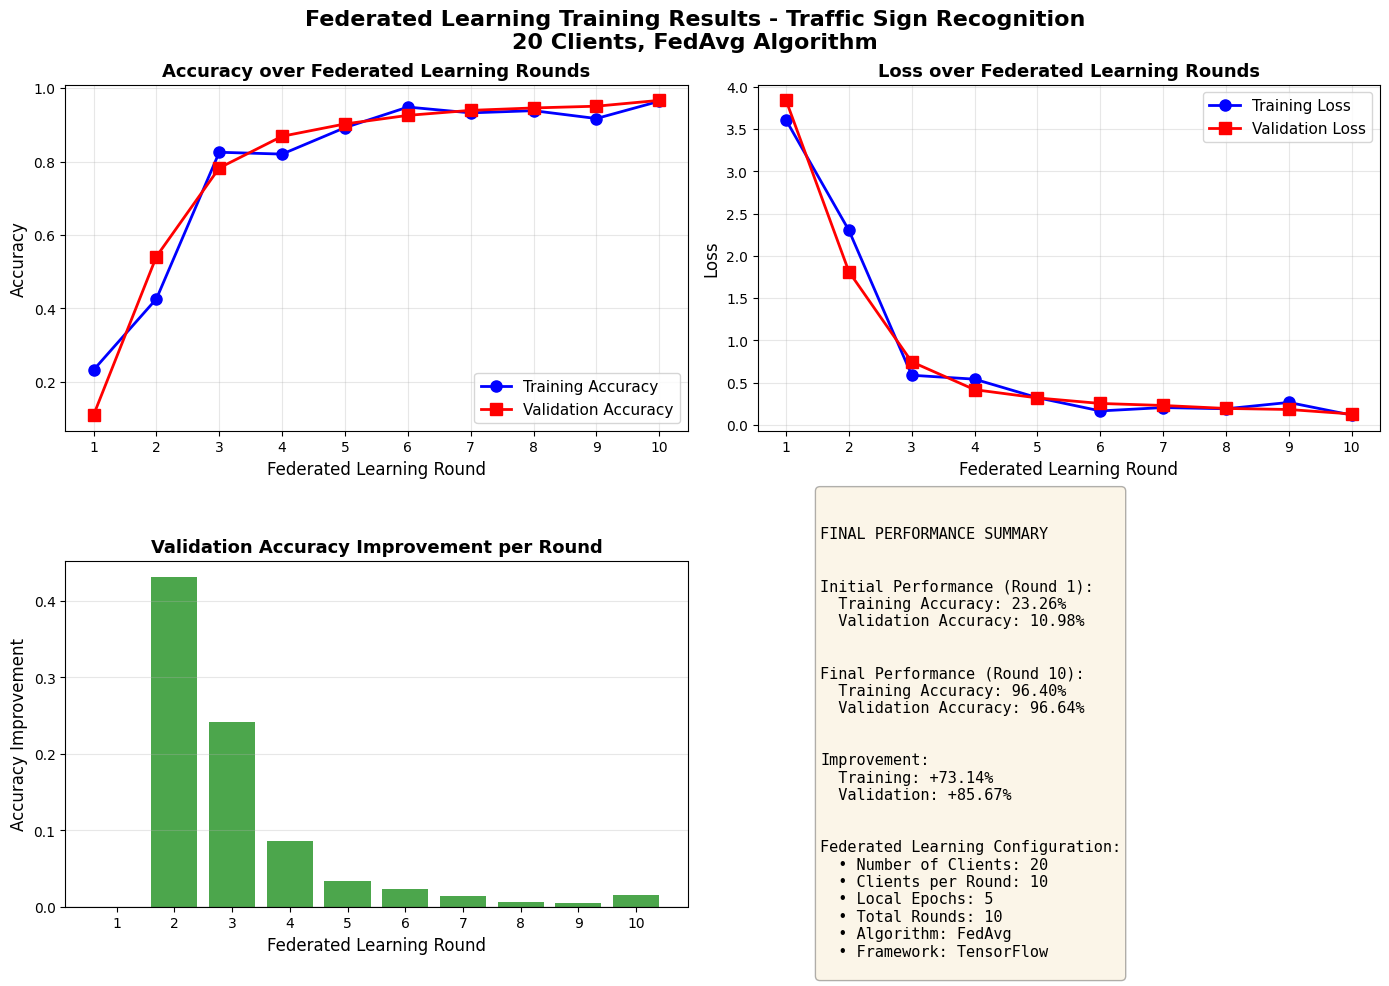


✓ Visualization complete!

Final Results:
  Training Accuracy: 96.40%
  Validation Accuracy: 96.64%
  Total Improvement: +85.67%


In [ ]:
# Plot Federated Learning Training Results
print("Creating visualizations...\n")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Federated Learning Training Results - Traffic Sign Recognition\n20 Clients, FedAvg Algorithm',
             fontsize=16, fontweight='bold')

# Plot 1: Training and Validation Accuracy
axes[0, 0].plot(history['round'], history['train_acc'], 'b-o', label='Training Accuracy', linewidth=2, markersize=8)
axes[0, 0].plot(history['round'], history['val_acc'], 'r-s', label='Validation Accuracy', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Federated Learning Round', fontsize=12)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy over Federated Learning Rounds', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(history['round'])

# Plot 2: Training and Validation Loss
axes[0, 1].plot(history['round'], history['train_loss'], 'b-o', label='Training Loss', linewidth=2, markersize=8)
axes[0, 1].plot(history['round'], history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Federated Learning Round', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Loss over Federated Learning Rounds', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(history['round'])

# Plot 3: Accuracy Improvement Rate
accuracy_improvement = [history['val_acc'][i] - history['val_acc'][i-1] if i > 0 else 0
                        for i in range(len(history['val_acc']))]
axes[1, 0].bar(history['round'], accuracy_improvement, color='green', alpha=0.7)
axes[1, 0].set_xlabel('Federated Learning Round', fontsize=12)
axes[1, 0].set_ylabel('Accuracy Improvement', fontsize=12)
axes[1, 0].set_title('Validation Accuracy Improvement per Round', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticks(history['round'])
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Plot 4: Final Performance Summary (Text)
axes[1, 1].axis('off')
summary_text = f"""\n\nFINAL PERFORMANCE SUMMARY\n\n
Initial Performance (Round 1):\n  Training Accuracy: {history['train_acc'][0]:.2%}\n  Validation Accuracy: {history['val_acc'][0]:.2%}\n\n
Final Performance (Round {history['round'][-1]}):\n  Training Accuracy: {history['train_acc'][-1]:.2%}\n  Validation Accuracy: {history['val_acc'][-1]:.2%}\n\n
Improvement:\n  Training: +{(history['train_acc'][-1] - history['train_acc'][0]):.2%}\n  Validation: +{(history['val_acc'][-1] - history['val_acc'][0]):.2%}\n\n
Federated Learning Configuration:\n  • Number of Clients: 20\n  • Clients per Round: 10\n  • Local Epochs: 5\n  • Total Rounds: 10\n  • Algorithm: FedAvg\n  • Framework: TensorFlow\n"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('federated_learning_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization complete!")
print(f"\nFinal Results:")
print(f"  Training Accuracy: {history['train_acc'][-1]:.2%}")
print(f"  Validation Accuracy: {history['val_acc'][-1]:.2%}")
print(f"  Total Improvement: +{(history['val_acc'][-1] - history['val_acc'][0]):.2%}")


# Summary

This notebook demonstrates the implementation of the Federated Averaging (FedAvg) algorithm using TensorFlow for a traffic sign classification task on the GTSRB dataset. We simulated a federated environment with 20 clients and distributed the training data in a non-IID manner using a Dirichlet distribution.

A CNN model was defined and trained iteratively over 10 federated learning rounds. In each round, a subset of clients trained the global model on their local data, and their updated model weights were aggregated by a central server to improve the global model.

The training progress was tracked by evaluating the global model's performance on a validation set after each round. The visualizations show the improvement in both training and validation accuracy, as well as the decrease in loss over the federated learning rounds.

# Conclusion

The Federated Averaging implementation successfully trained a traffic sign classification model in a simulated federated setting. The model's performance, as measured by validation accuracy, improved significantly over the training rounds, demonstrating the effectiveness of the FedAvg algorithm in aggregating knowledge from distributed clients without requiring their raw data to be centrally collected.

This example highlights the potential of federated learning for training models on decentralized data while preserving data privacy. Further work could explore different federated learning algorithms, varying the number of clients and communication rounds, and applying this approach to other datasets and model architectures.